# Import der genutzten Bibliotheken

Installiere die notwendigen Bibliotheken, falls notwendig

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
# import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.seasonal import STL
import ipywidgets as widgets
from IPython.display import display, clear_output
import yfinance as yf

#register_matplotlib_converters()
#sns.set_style("darkgrid")

In [2]:
#plt.rc("figure", figsize=(16, 12))
#plt.rc("font", size=13)

# Datensatz einlesen: "Monthly car sales"

Ein Automobilhersteller möchte seine monatlichen Verkaufszahlen analysieren, um langfristige Entwicklungen und saisonale Effekte besser zu verstehen.

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"

df_carSales = pd.read_csv(url)
df_carSales["Month"] = pd.to_datetime(df_carSales["Month"])
df_carSales.set_index("Month", inplace=True)

df_carSales.head()

,Sales
Month,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


# Aufgabe 1:

1. Visualisiere die Zeitreihe.
2. Führe eine STL-Zerlegung mit period=12 durch.
3. Überführe die zerlegten Zeitreihen in ein lesbares Data-Frame zur Weiterverarbeitung.
4. Warum ist eine Trennung von Trend und Saison für spätere Prognosemodelle hilfreich?

# Musterlösung 1.1

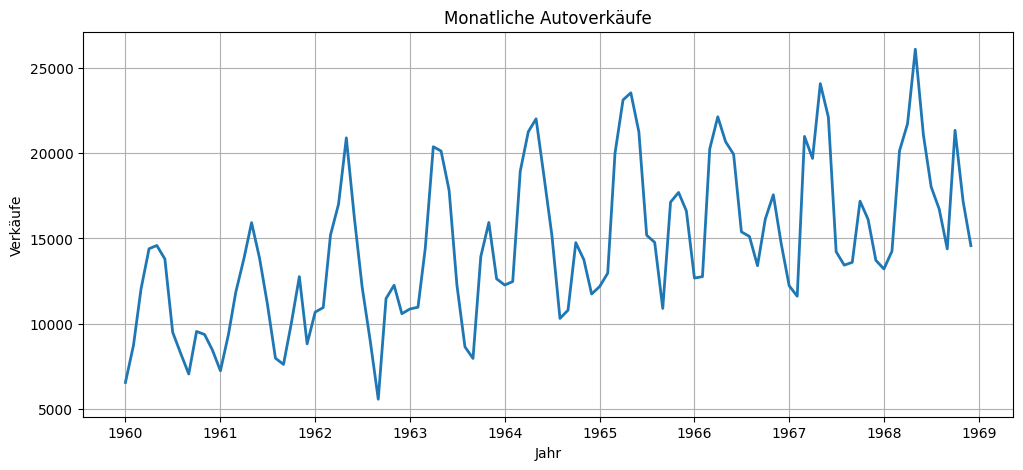

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df_carSales.index,
         df_carSales["Sales"],
         linewidth=2)

plt.title("Monatliche Autoverkäufe")
plt.xlabel("Jahr")
plt.ylabel("Verkäufe")
plt.grid(True)

plt.show()

# Musterlösung 1.2

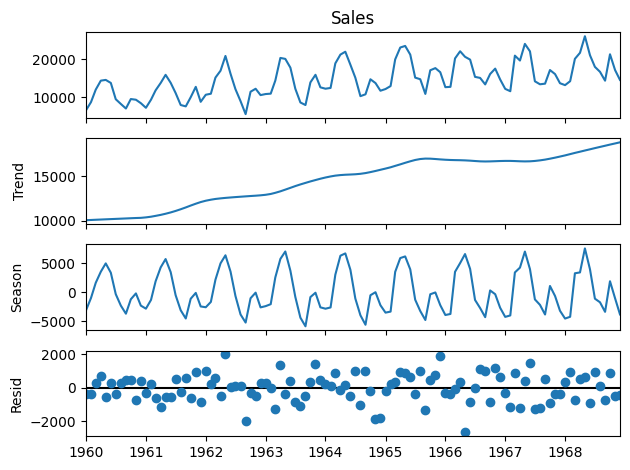

In [ ]:
stl = STL(df_carSales["Sales"], period=12)
result = stl.fit()
result.plot()
plt.show()

# Musterlösung 1.3

In [ ]:
df_stl = pd.DataFrame({
    "Original": result.observed,
    "Trend": result.trend,
    "Saison": result.seasonal,
    "Residuum": result.resid
})

df_stl.head()

,Original,Trend,Saison,Residuum
Month,,,,
1960-01-01,6550,10064.908952,-3139.405933,-375.503019
1960-02-01,8728,10091.426201,-988.315996,-375.110204
1960-03-01,12026,10116.794039,1616.502798,292.703163
1960-04-01,14395,10141.479989,3521.521044,731.998968
1960-05-01,14587,10165.859033,4942.558590,-521.417623


# Musterlösung 1.4

Die Trennung von Trend und Saison ist hilfreich, weil die regelmäßig wiederkehrende Saisonkomponente separat behandelt werden kann. 
Die saisonale Komponente wird aus der Zeitreihe entfernt und ein Prognosemodell, z. B. ARIMA, auf die deseasonalisierte Zeitreihe angewendet. 
Diese enthält weiterhin Trend- und Restkomponenten. 
Anschließend wird die saisonale Komponente für den Prognosezeitraum fortgeschrieben und wieder zur Prognose addiert.

# Aufgabe 2: 

1. Führe die nachfolgende Zelle aus.
2. Nutze die Schieberegler, um die optimalen Parameter für die STL-Zerlegung zu finden.
3. Beschreibe, wie die Parameter period, seasonal, trend und robust jeweils das Ergebnis beeinflussen
4. Welcher Parameter hat den größten Einfluss? Wie wird er bestimmt?

In [9]:
def plot_stl(period=12, seasonal=13, trend=21, robust=True):
    clear_output(wait=True)

    # STL benötigt ungerade Werte für seasonal und trend
    if seasonal % 2 == 0:
        seasonal += 1
    if trend % 2 == 0:
        trend += 1

    result = STL(
        df_carSales,
        period=period,
        seasonal=seasonal,
        trend=trend,
        robust=robust
    ).fit()

    fig = result.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle(
        f"STL-Zerlegung: period={period}, seasonal={seasonal}, trend={trend}, robust={robust}",
        y=1.02
    )
    plt.show()


period_slider = widgets.IntSlider(
    value=12,
    min=2,
    max=52,
    step=1,
    description="period"
)

seasonal_slider = widgets.IntSlider(
    value=13,
    min=7,
    max=51,
    step=2,
    description="seasonal"
)

trend_slider = widgets.IntSlider(
    value=21,
    min=7,
    max=101,
    step=2,
    description="trend"
)

robust_checkbox = widgets.Checkbox(
    value=True,
    description="robust"
)

ui = widgets.VBox([
    period_slider,
    seasonal_slider,
    trend_slider,
    robust_checkbox,
])

out = widgets.interactive_output(
    plot_stl,
    {
        "period": period_slider,
        "seasonal": seasonal_slider,
        "trend": trend_slider,
        "robust": robust_checkbox
    }
)

display(ui, out)

Output()

# Musterlösung 2.3

period:

Der Parameter period gibt die Länge eines vollständigen saisonalen Zyklus an.

Monatsdaten → period = 12
Tagesdaten mit Wochenmuster → period = 7
Vierteljährliche Daten → period = 4

Ist die Periodenlänge falsch gewählt, kann STL die saisonalen Muster nicht korrekt erkennen. Dadurch werden Trend- und Residualkomponente ebenfalls fehlerhaft geschätzt.

seasonal:

Der Parameter seasonal bestimmt die Fenstergröße der LOESS-Glättung zur Schätzung der Saisonkomponente.

kleiner Wert:
Saison folgt kurzfristigen Schwankungen stärker,
Gefahr des Overfittings.
großer Wert:
Saison wird stärker geglättet,
kleine saisonale Veränderungen werden unterdrückt.

Der Wert muss ungerade sein.

trend:

Der Parameter trend bestimmt die Fenstergröße der LOESS-Glättung zur Schätzung des Trends.

kleiner Wert:
Trend reagiert schneller auf Änderungen,
kann kurzfristige Schwankungen fälschlicherweise als Trend interpretieren.
großer Wert:
Trend verläuft deutlich glatter,
kurzfristige Veränderungen verbleiben eher im Residuum.

Auch dieser Wert muss ungerade sein.

robust:

robust aktiviert eine robuste STL-Schätzung.

False
alle Beobachtungen werden gleich gewichtet.
True
Ausreißer erhalten während der Iterationen ein geringeres Gewicht,
Trend und Saison werden weniger von Extremwerten beeinflusst.

Dieser Parameter ist besonders sinnvoll bei Messfehlern oder einzelnen ungewöhnlichen Beobachtungen.

# Musterlösung 2.4

Der wichtigste Parameter ist period.

Er legt fest, nach wie vielen Beobachtungen sich die Saison wiederholt und bestimmt damit die grundlegende Struktur der Zerlegung. Eine falsche Periodenlänge führt dazu, dass die Saisonkomponente nicht korrekt erkannt wird. Dies wirkt sich unmittelbar auch auf Trend und Residuum aus.

Die Periodenlänge wird nicht automatisch optimiert, sondern stammt in der Regel aus dem Fachwissen über den Datensatz: